# WAREHOUSE DATA ANALYSIS

## Project Introduction

Inventory management is an important part of warehouse and supply-chain operations. 
Organizations need to maintain sufficient stock to satisfy customer demand while avoiding 
excess inventory, high holding costs, stockouts, and delayed orders.

This project analyzes warehouse inventory data to understand demand patterns, supplier 
performance, stock availability, inventory efficiency, product quality, and warehouse 
demand pressure.

The analysis uses Exploratory Data Analysis (EDA), descriptive statistics, correlation 
analysis, group-wise analysis, and visualizations to identify important patterns and 
answer business-related inventory questions.

## Project Deliverables

The major deliverables of this project are:

1. Data acquisition.
2. Data understanding and basic inspection.
3. Missing-value analysis.
4. Duplicate-value analysis.
5. Descriptive statistical analysis.
6. Product-category analysis.
7. Warehouse-zone analysis.
8. Supplier performance analysis.
9. Inventory efficiency analysis.
10. Stockout and backorder analysis.
11. Reorder-point analysis.
12. Safety-stock and excess-stock analysis.
13. Inventory cost analysis.
14. Product return and damage analysis.
15. Warehouse demand pressure analysis.
16. Visualization of important findings.
17. Cell-by-cell interpretation.
18. Final business conclusions.

## My Role 

As a **Data Science Intern**, my responsibilities in this project are:

* Understand the warehouse inventory dataset and the business problem.
* Perform data understanding and exploratory data analysis (EDA).
* Check data types, missing values, and duplicate records.
* Analyze numerical and categorical variables.
* Create visualizations using **Matplotlib and Seaborn**.
* Identify important patterns and relationships in warehouse inventory data.
* Preprocess the data by encoding categorical variables.
* Scale numerical variables using **StandardScaler**.
* Prepare the final feature set for clustering.
* Apply **K-Means Clustering** to group products based on similar inventory characteristics.
* Use the **Elbow Method** to determine the optimal number of clusters.
* Analyze and interpret the clusters.
* Use **PCA visualization** to visualize the clusters.
* Identify meaningful inventory groups and derive insights from the clustering results.


## Data Description

The dataset contains 4,000 product-level observations and 25 columns.

The variables represent:

- Product information
- Product category and subcategory
- Supplier information
- Warehouse zone
- Monthly demand
- Demand variability
- Supplier lead time
- Lead-time variability
- Reorder activity
- Stock turnover
- Days in inventory
- Stockouts
- Backorders
- Return rate
- Damage rate
- Holding cost
- Unit cost
- Reorder-point breaches
- Supplier delay incidents
- Current stock
- Safety stock
- Excess stock
- Inventory value
- Warehouse demand pressure

The main columns used in this project are:

| Column | Description |
|---|---|
| `item_id` | Unique product identifier |
| `category` | Product category |
| `subcategory` | Product subcategory |
| `supplier_id` | Supplier identifier |
| `warehouse_zone` | Warehouse zone |
| `avg_monthly_demand` | Average monthly demand |
| `demand_variability` | Variability in product demand |
| `avg_lead_time_days` | Average supplier lead time |
| `lead_time_variability` | Variability in supplier lead time |
| `monthly_reorder_count` | Number of monthly reorders |
| `stock_turnover_ratio` | Inventory turnover ratio |
| `days_in_inventory` | Number of days inventory remains in stock |
| `stockout_frequency` | Frequency of stockouts |
| `backorder_frequency` | Frequency of backorders |
| `return_rate` | Product return rate |
| `damage_rate` | Product damage rate |
| `holding_cost_per_unit` | Holding cost per unit |
| `unit_cost` | Product unit cost |
| `reorder_point_breaches` | Number of reorder-point breaches |
| `supplier_delay_incidents` | Supplier delay incidents |
| `current_stock` | Current inventory level |
| `safety_stock` | Safety stock level |
| `excess_stock_level` | Excess inventory level |
| `inventory_value` | Total inventory value |
| `warehouse_demand_pressure_index` | Warehouse demand pressure measure |

## Data Acquisition

In [99]:
# Importing the required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Loading the training dataset
df = pd.read_csv("/Users/keva/Downloads/warehouse_inventory_clustering_dataset.csv")

In [100]:
# Displaying the first 5 rows of the dataset

df.head()

,item_id,category,subcategory,supplier_id,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,...,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
0,ITM00001,Grocery,Snacks,S1036,B2,310,0.26,7.8,0.05,8,...,0.012,10.83,132.98,1,2,249,75,46,33112.02,161.12
1,ITM00002,Industrial,Electrical Parts,S1036,B1,455,0.16,4.8,0.08,8,...,0.007,45.57,1525.56,0,0,362,94,34,552252.72,141.27
2,ITM00003,Apparel,Jackets,S1011,B2,350,0.43,20.9,0.57,6,...,0.010,18.47,457.56,3,9,317,105,146,145046.52,238.29
3,ITM00004,Automotive,Lubricants,S1030,A1,121,0.33,4.6,0.12,1,...,0.017,168.71,1779.38,0,1,183,32,84,325626.54,87.90
4,ITM00005,Pharmaceutical,Medical Devices,S1064,A2,85,0.14,7.3,0.15,1,...,0.016,33.33,731.83,2,4,209,17,180,152952.47,86.85


In [101]:
# Displaying the last 5 rows of the dataset

df.tail()

,item_id,category,subcategory,supplier_id,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,...,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
3995,ITM03996,Pharmaceutical,OTC Medicine,S1003,C2,61,0.33,7.3,0.35,3,...,0.019,12.12,404.91,0,0,274,16,248,110945.34,28.77
3996,ITM03997,Automotive,Batteries,S1007,C1,487,0.40,13.8,0.50,6,...,0.026,45.95,844.98,10,5,371,141,18,313487.58,245.03
3997,ITM03998,Industrial,Fasteners,S1064,D2,32,0.61,10.9,0.36,2,...,0.020,60.67,1743.43,2,2,200,12,174,348686.00,56.08
3998,ITM03999,Stationery,Writing Tools,S1056,D1,571,0.42,11.8,0.41,11,...,0.015,4.62,132.21,5,12,511,170,52,67559.31,200.31
3999,ITM04000,Pharmaceutical,OTC Medicine,S1022,A1,540,0.13,6.4,0.08,7,...,0.018,11.49,218.83,2,1,453,106,8,99129.99,130.47


In [102]:
# Checking the data types of all columns

df.dtypes

item_id                             object
category                            object
subcategory                         object
supplier_id                         object
warehouse_zone                      object
avg_monthly_demand                   int64
demand_variability                 float64
avg_lead_time_days                 float64
lead_time_variability              float64
monthly_reorder_count                int64
stock_turnover_ratio               float64
days_in_inventory                    int64
stockout_frequency                   int64
backorder_frequency                  int64
return_rate                        float64
damage_rate                        float64
holding_cost_per_unit              float64
unit_cost                          float64
reorder_point_breaches               int64
supplier_delay_incidents             int64
current_stock                        int64
safety_stock                         int64
excess_stock_level                   int64
inventory_v

In [8]:
# Getting basic information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   item_id                          4000 non-null   object 
 1   category                         4000 non-null   object 
 2   subcategory                      4000 non-null   object 
 3   supplier_id                      4000 non-null   object 
 4   warehouse_zone                   4000 non-null   object 
 5   avg_monthly_demand               4000 non-null   int64  
 6   demand_variability               4000 non-null   float64
 7   avg_lead_time_days               4000 non-null   float64
 8   lead_time_variability            4000 non-null   float64
 9   monthly_reorder_count            4000 non-null   int64  
 10  stock_turnover_ratio             4000 non-null   float64
 11  days_in_inventory                4000 non-null   int64  
 12  stockout_frequency  

In [9]:
# Checking for missing values in each column

df.isnull().sum()

item_id                            0
category                           0
subcategory                        0
supplier_id                        0
warehouse_zone                     0
avg_monthly_demand                 0
demand_variability                 0
avg_lead_time_days                 0
lead_time_variability              0
monthly_reorder_count              0
stock_turnover_ratio               0
days_in_inventory                  0
stockout_frequency                 0
backorder_frequency                0
return_rate                        0
damage_rate                        0
holding_cost_per_unit              0
unit_cost                          0
reorder_point_breaches             0
supplier_delay_incidents           0
current_stock                      0
safety_stock                       0
excess_stock_level                 0
inventory_value                    0
warehouse_demand_pressure_index    0
dtype: int64

In [10]:
# Removing duplicate rows if any duplicates are present

df = df.drop_duplicates()

In [11]:
# Checking the dataset size after removing duplicates

df.shape

(4000, 25)

In [12]:
# Getting statistical summary of numerical columns

df.describe()

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,stockout_frequency,backorder_frequency,return_rate,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4000.00000
mean,331.809250,0.285640,10.301275,0.258738,4.707250,5.944282,65.489750,2.491250,1.938000,0.028485,0.015713,47.709973,804.380267,2.657250,3.239750,317.102000,80.002750,104.915750,2.491254e+05,159.10009
std,228.438284,0.128173,5.592473,0.165963,2.991118,3.804082,56.855528,3.192487,2.503642,0.015560,0.008412,50.174326,741.472968,3.498976,3.615873,136.958627,55.192937,106.302228,2.508303e+05,88.27321
min,1.000000,0.080000,1.000000,0.050000,0.000000,0.200000,4.000000,0.000000,0.000000,0.005000,0.002000,0.520000,20.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000e+00,5.00000
25%,103.000000,0.190000,6.200000,0.130000,2.000000,2.140000,22.000000,0.000000,0.000000,0.017000,0.009000,12.565000,220.160000,0.000000,0.000000,219.000000,27.000000,32.000000,6.278350e+04,82.77000
50%,333.000000,0.260000,9.000000,0.200000,5.000000,6.150000,34.000000,1.000000,1.000000,0.026000,0.015000,33.710000,652.130000,1.000000,2.000000,304.000000,80.000000,60.000000,1.759532e+05,151.79500
75%,523.250000,0.370000,13.400000,0.360000,7.000000,9.140000,106.000000,4.000000,3.000000,0.037000,0.020000,64.495000,1108.817500,4.000000,5.000000,403.000000,122.000000,150.000000,3.498038e+05,228.21000
max,983.000000,0.620000,35.000000,0.720000,14.000000,15.890000,273.000000,15.000000,14.000000,0.080000,0.040000,502.570000,6085.330000,17.000000,18.000000,908.000000,306.000000,622.000000,2.093354e+06,300.00000


# ASSESSMENT QUESTIONS:

In [13]:
# Q1: How does average monthly demand vary across different product categories?

df.groupby('category')['avg_monthly_demand'].mean().sort_values(ascending=False)

category
Pharmaceutical    354.012024
Industrial        342.108108
Home & Kitchen    335.700405
Automotive        333.521822
Apparel           331.339216
Stationery        327.657895
Grocery           317.458696
Electronics       311.032129
Name: avg_monthly_demand, dtype: float64

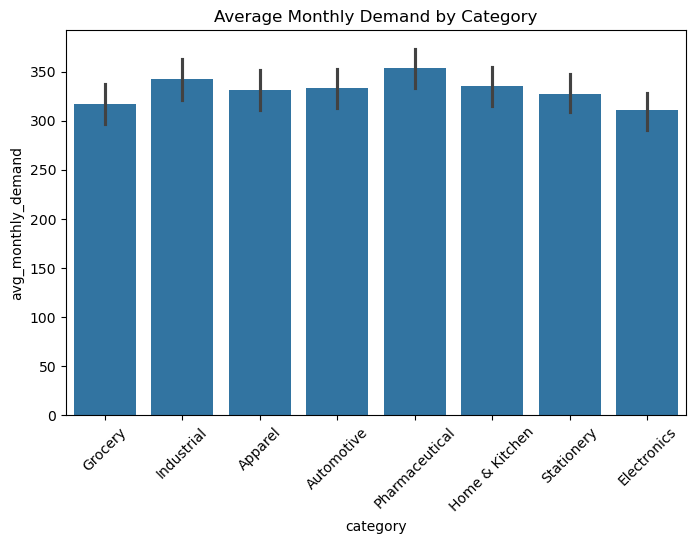

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x='category', y='avg_monthly_demand', data=df)
plt.xticks(rotation=45)
plt.title("Average Monthly Demand by Category")
plt.show()

### Observation
Pharmaceutical products have the highest average monthly demand, followed by Industrial products. Electronics has the lowest average monthly demand among the categories. This indicates that pharmaceutical products have the strongest overall demand.

In [15]:
# Q2: Which product categories show the highest demand variability?

df.groupby('category')['demand_variability'].mean().sort_values(ascending=False)

category
Electronics       0.295663
Grocery           0.291500
Home & Kitchen    0.287652
Automotive        0.287173
Stationery        0.287045
Industrial        0.280637
Pharmaceutical    0.278337
Apparel           0.277902
Name: demand_variability, dtype: float64

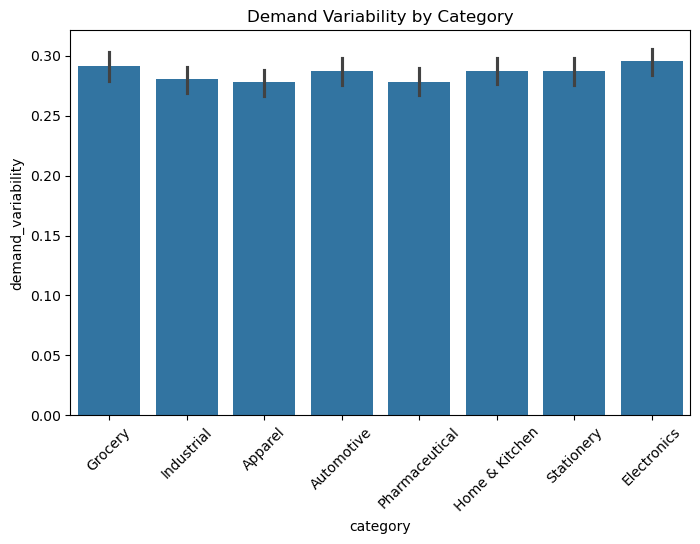

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='category',
    y='demand_variability',
    data=df,
    estimator='mean'
)
plt.xticks(rotation=45)
plt.title("Demand Variability by Category")
plt.show()

### Observation
Electronics has the highest average demand variability, followed by Grocery and Home & Kitchen. Apparel has the lowest demand variability. Therefore, Electronics demand is comparatively less stable.

In [17]:
# Q3: Which warehouse zones handle products with the highest average demand?

df.groupby('warehouse_zone')['avg_monthly_demand'].mean().sort_values(ascending=False)

warehouse_zone
D1    344.346939
C2    340.298805
B2    338.925847
C1    330.073260
B1    328.317719
A1    325.836327
D2    324.181633
A2    323.202756
Name: avg_monthly_demand, dtype: float64

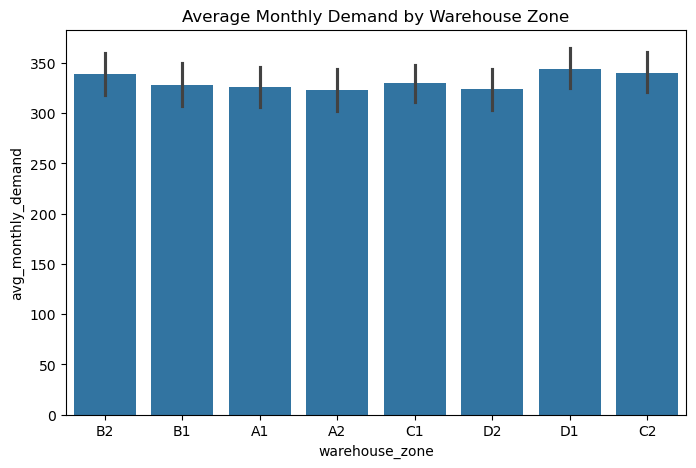

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(x='warehouse_zone', y='avg_monthly_demand', data=df)
plt.title("Average Monthly Demand by Warehouse Zone")
plt.show()

### Observation
Warehouse zone D1 handles products with the highest average monthly demand, followed by C2 and B2. Zone A2 has the lowest average demand. This suggests that D1 experiences comparatively higher demand pressure.

In [19]:
# Q4: Which products have the longest average supplier lead times?

df[['item_id', 'avg_lead_time_days']].sort_values('avg_lead_time_days', ascending=False).head(10)

,item_id,avg_lead_time_days
1916,ITM01917,35.0
1308,ITM01309,35.0
39,ITM00040,35.0
379,ITM00380,33.9
925,ITM00926,33.6
2558,ITM02559,32.0
3566,ITM03567,31.9
1664,ITM01665,30.8
1788,ITM01789,30.6
331,ITM00332,30.6


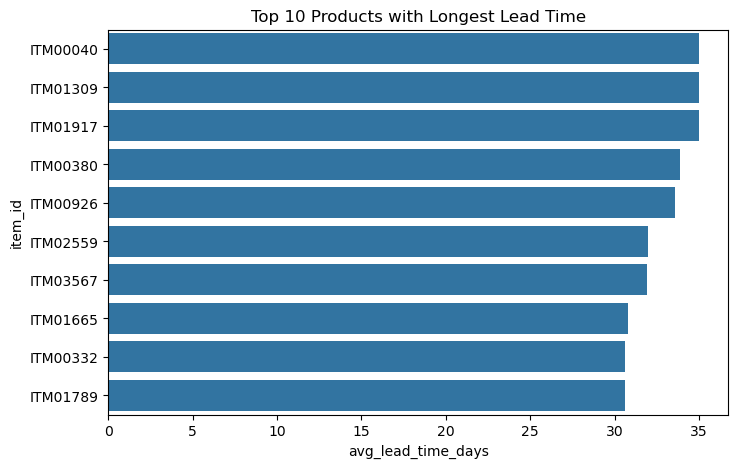

In [20]:
top10 = df.nlargest(10, 'avg_lead_time_days')

plt.figure(figsize=(8,5))
sns.barplot(x='avg_lead_time_days', y='item_id', data=top10)
plt.title("Top 10 Products with Longest Lead Time")
plt.show()

### Observation
The products with the longest supplier lead times include ITM00040, ITM01309 and ITM01917, each having a lead time of 35 days. These products may require better procurement planning because delays can affect inventory availability.

In [21]:
# Q5: Is high lead-time variability associated with more supplier delay incidents?

print("Correlation:", round(df['lead_time_variability'].corr(df['supplier_delay_incidents']), 2))

Correlation: 0.72


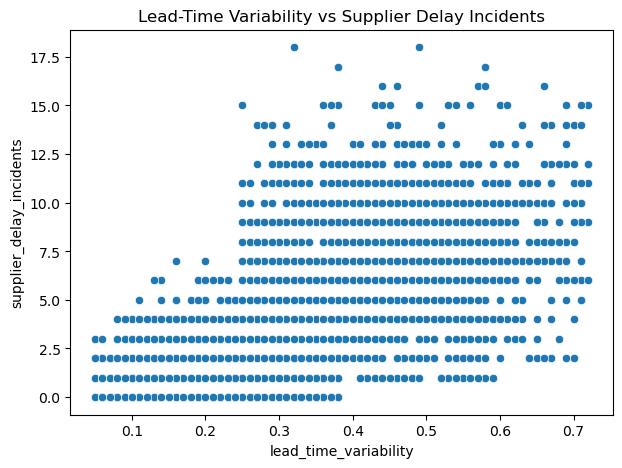

In [22]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='lead_time_variability',
    y='supplier_delay_incidents',
    data=df
)
plt.title("Lead-Time Variability vs Supplier Delay Incidents")
plt.show()

### Observation
The correlation between lead-time variability and supplier delay incidents is approximately 0.72. This indicates a strong positive relationship. Products with higher lead-time variability tend to experience more supplier delay incidents.

In [23]:
# Q6: Which products have the highest stock turnover ratios?

df[['item_id', 'stock_turnover_ratio']].sort_values('stock_turnover_ratio', ascending=False).head(10)

,item_id,stock_turnover_ratio
426,ITM00427,15.89
2464,ITM02465,15.69
2779,ITM02780,15.34
1418,ITM01419,15.18
2842,ITM02843,15.01
1128,ITM01129,15.00
3702,ITM03703,15.00
3621,ITM03622,15.00
3404,ITM03405,15.00
1765,ITM01766,14.94


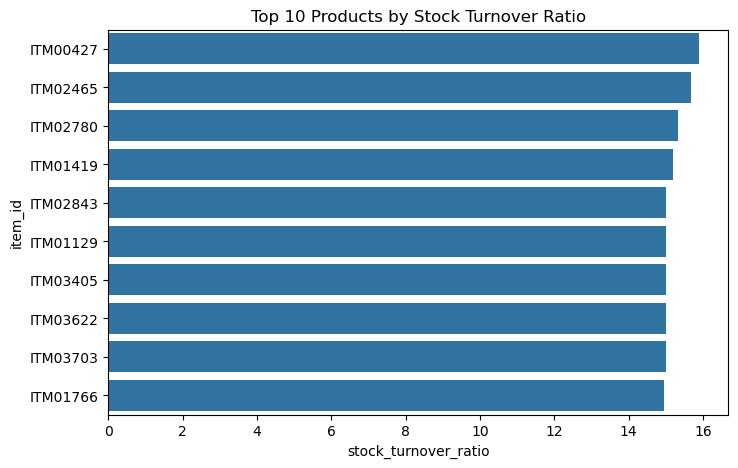

In [24]:
top10 = df.nlargest(10, 'stock_turnover_ratio')

plt.figure(figsize=(8,5))
sns.barplot(x='stock_turnover_ratio', y='item_id', data=top10)
plt.title("Top 10 Products by Stock Turnover Ratio")
plt.show()

### Observation
ITM00427 has the highest stock turnover ratio at approximately 15.89, followed by ITM02465 and ITM02780. These products are moving through inventory very quickly compared with other products.

In [25]:
# Q7: Which products remain in inventory for the longest number of days?

df[['item_id', 'days_in_inventory']].sort_values('days_in_inventory', ascending=False).head(10)

,item_id,days_in_inventory
643,ITM00644,273
2772,ITM02773,272
3078,ITM03079,268
680,ITM00681,261
3722,ITM03723,258
1179,ITM01180,252
2295,ITM02296,249
547,ITM00548,247
1373,ITM01374,246
2693,ITM02694,246


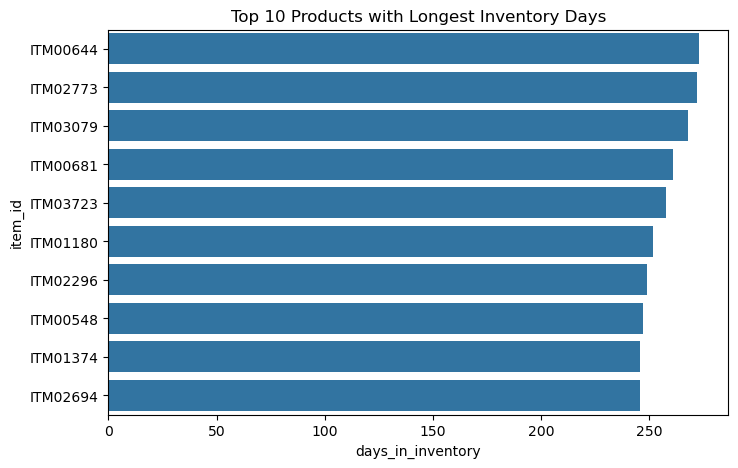

In [26]:
top10 = df.nlargest(10, 'days_in_inventory')

plt.figure(figsize=(8,5))
sns.barplot(x='days_in_inventory', y='item_id', data=top10)
plt.title("Top 10 Products with Longest Inventory Days")
plt.show()

### Observation
ITM00644 has the highest number of days in inventory at 273 days, followed by ITM02773 at 272 days. These products remain in inventory for a long period and may indicate slow inventory movement.

In [27]:
# Q8: Is there a relationship between stock turnover ratio and days in inventory?

print("Correlation:", round(df['stock_turnover_ratio'].corr(df['days_in_inventory']), 2))

Correlation: -0.76


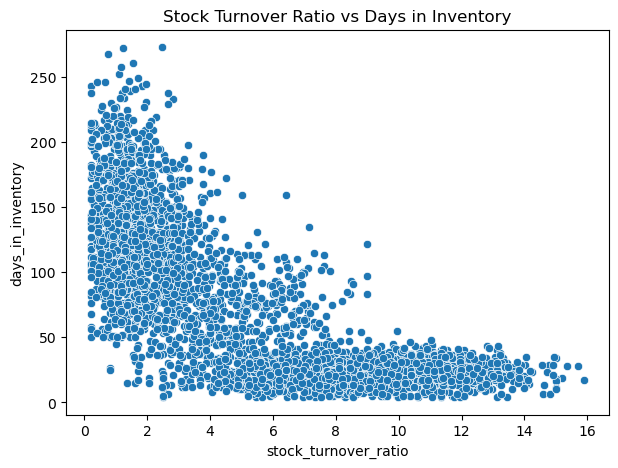

In [28]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='stock_turnover_ratio',
    y='days_in_inventory',
    data=df
)
plt.title("Stock Turnover Ratio vs Days in Inventory")
plt.show()

### Observation
The correlation is approximately -0.76, showing a strong negative relationship. Products with higher stock turnover generally have fewer days in inventory. This means faster-moving products tend to stay in inventory for a shorter period.

In [29]:
# Q9: Which products experience the highest stockout frequency?

df[['item_id', 'stockout_frequency']].sort_values('stockout_frequency', ascending=False).head(10)

,item_id,stockout_frequency
2971,ITM02972,15
3757,ITM03758,15
3422,ITM03423,15
3624,ITM03625,15
2849,ITM02850,15
1626,ITM01627,15
2284,ITM02285,15
2255,ITM02256,15
2536,ITM02537,15
1901,ITM01902,15


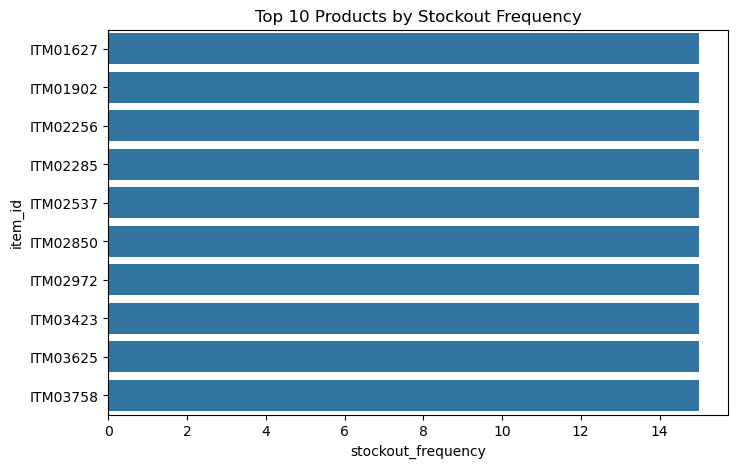

In [30]:
top10 = df.nlargest(10, 'stockout_frequency')

plt.figure(figsize=(8,5))
sns.barplot(x='stockout_frequency', y='item_id', data=top10)
plt.title("Top 10 Products by Stockout Frequency")
plt.show()

### Observation
The top products have a stockout frequency of 15 incidents. Several products share this highest value, indicating that these products experience frequent stock shortages and may require improved inventory planning.

In [31]:
# Q10: Are products with high demand variability more likely to experience stockouts?

print("Correlation:", round(df['demand_variability'].corr(df['stockout_frequency']), 2))

Correlation: 0.37


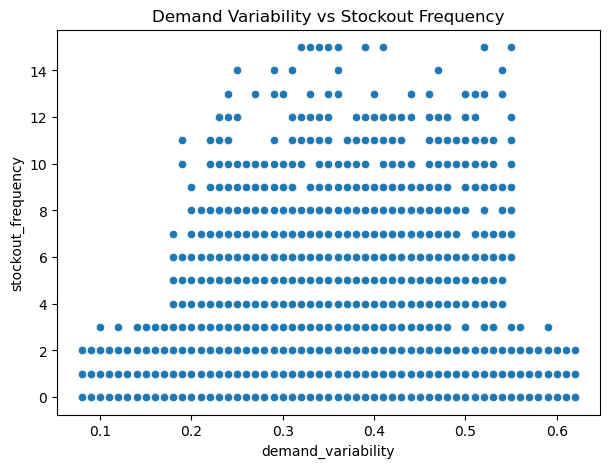

In [32]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='demand_variability',
    y='stockout_frequency',
    data=df
)
plt.title("Demand Variability vs Stockout Frequency")
plt.show()

### Observation
The correlation is approximately 0.37, indicating a moderate positive relationship. Products with higher demand variability tend to experience more stockouts, although demand variability is not the only factor affecting stockouts.

In [33]:
# Q11: Which products experience frequent backorders?

df[['item_id', 'backorder_frequency']].sort_values('backorder_frequency', ascending=False).head(10)

,item_id,backorder_frequency
1458,ITM01459,14
1871,ITM01872,13
3741,ITM03742,13
3981,ITM03982,13
2143,ITM02144,13
3812,ITM03813,13
2374,ITM02375,13
1993,ITM01994,12
3097,ITM03098,12
3092,ITM03093,12


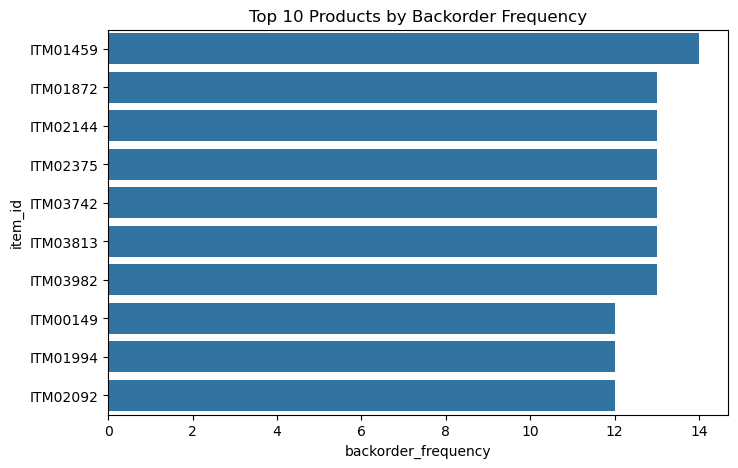

In [34]:
top10 = df.nlargest(10, 'backorder_frequency')

plt.figure(figsize=(8,5))
sns.barplot(x='backorder_frequency', y='item_id', data=top10)
plt.title("Top 10 Products by Backorder Frequency")
plt.show()

### Observation
ITM01459 has the highest backorder frequency with 14 incidents. Several other products have 13 or 12 incidents. These products may have insufficient available stock to satisfy demand on time.

In [35]:
# Q12: Is backorder frequency associated with stockout frequency?

print("Correlation:", round(df['backorder_frequency'].corr(df['stockout_frequency']), 2))

Correlation: 0.66


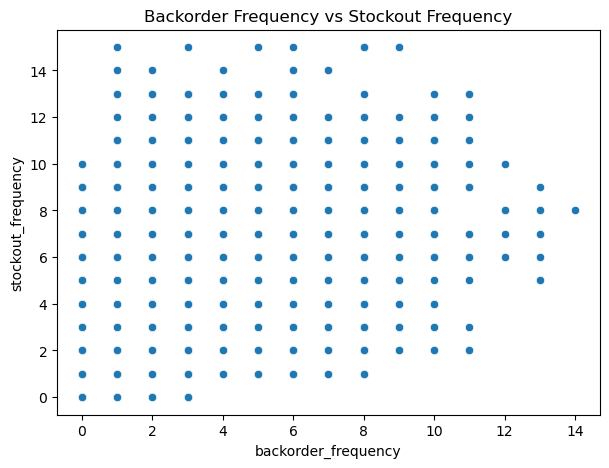

In [36]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='backorder_frequency',
    y='stockout_frequency',
    data=df
)
plt.title("Backorder Frequency vs Stockout Frequency")
plt.show()

### Observation
The correlation is approximately 0.66, showing a moderately strong positive relationship. Products experiencing more stockouts also tend to experience more backorders.

In [37]:
# Q13: Which products have the highest reorder-point breaches?

df[['item_id', 'reorder_point_breaches']].sort_values('reorder_point_breaches', ascending=False).head(10)

,item_id,reorder_point_breaches
241,ITM00242,17
648,ITM00649,17
2341,ITM02342,16
1547,ITM01548,16
3236,ITM03237,16
3246,ITM03247,15
1143,ITM01144,15
2824,ITM02825,15
2269,ITM02270,15
2157,ITM02158,15


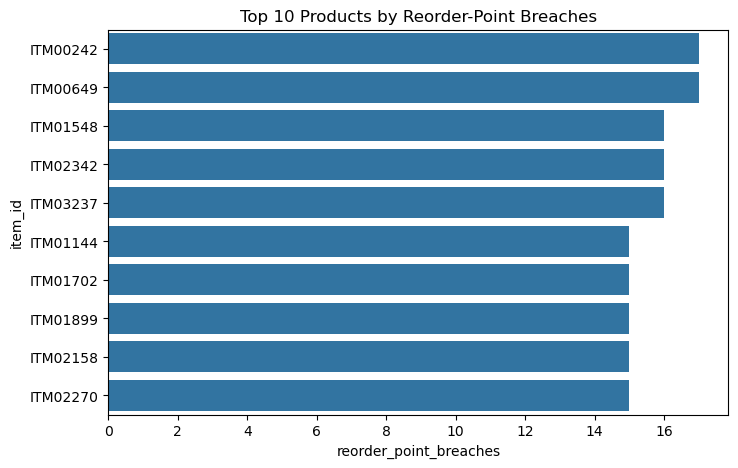

In [38]:
top10 = df.nlargest(10, 'reorder_point_breaches')

plt.figure(figsize=(8,5))
sns.barplot(x='reorder_point_breaches', y='item_id', data=top10)
plt.title("Top 10 Products by Reorder-Point Breaches")
plt.show()

### Observation
ITM00649 and ITM00242 have the highest number of reorder-point breaches, with 17 breaches each. These products frequently fall below their reorder points and may require closer inventory monitoring.

In [39]:
# Q14: Do products with frequent reorder-point breaches also have high monthly reorder counts?

print("Correlation:", round(df['reorder_point_breaches'].corr(df['monthly_reorder_count']), 2))

Correlation: 0.34


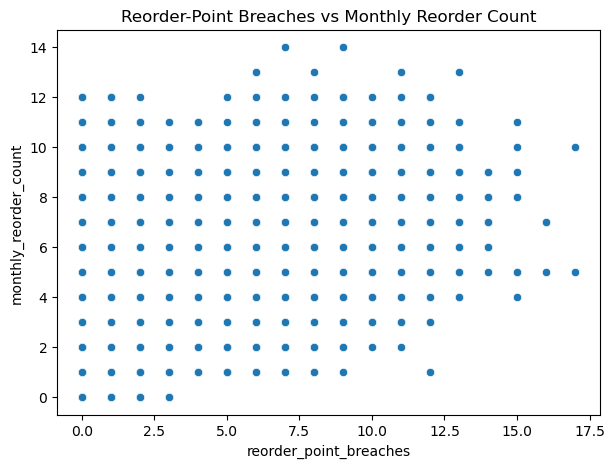

In [40]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='reorder_point_breaches',
    y='monthly_reorder_count',
    data=df
)
plt.title("Reorder-Point Breaches vs Monthly Reorder Count")
plt.show()

### Observation
The correlation is approximately 0.34, indicating a moderate positive relationship. Products with more reorder-point breaches tend to have somewhat higher monthly reorder counts.

In [41]:
# Q15: Which products have the highest supplier delay incidents?

df[['item_id', 'supplier_delay_incidents']].sort_values('supplier_delay_incidents', ascending=False).head(10)

,item_id,supplier_delay_incidents
1305,ITM01306,18
1805,ITM01806,18
2229,ITM02230,17
191,ITM00192,17
2515,ITM02516,16
365,ITM00366,16
2622,ITM02623,16
1127,ITM01128,16
1475,ITM01476,16
3161,ITM03162,15


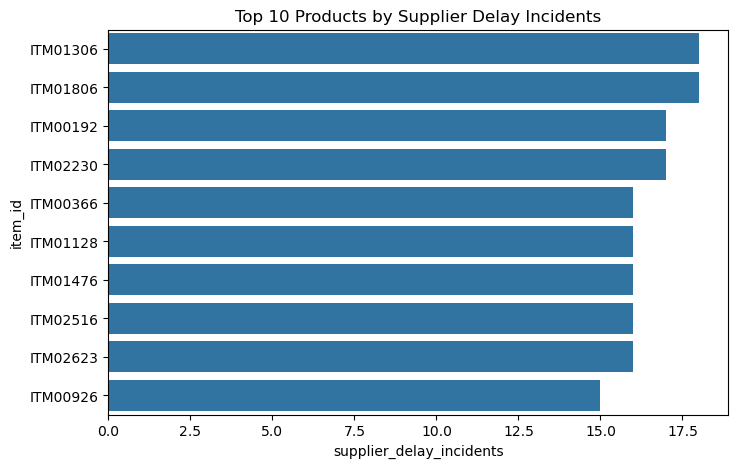

In [42]:
top10 = df.nlargest(10, 'supplier_delay_incidents')

plt.figure(figsize=(8,5))
sns.barplot(x='supplier_delay_incidents', y='item_id', data=top10)
plt.title("Top 10 Products by Supplier Delay Incidents")
plt.show()

### Observation
ITM01306 and ITM01806 have the highest supplier delay incidents, with 18 incidents each. These products may require closer supplier monitoring and alternative sourcing strategies.

In [43]:
# Q16: Is supplier delay associated with increased stockouts or backorders?

print("Supplier delay vs stockouts:",
      round(df['supplier_delay_incidents'].corr(df['stockout_frequency']), 2))

print("Supplier delay vs backorders:",
      round(df['supplier_delay_incidents'].corr(df['backorder_frequency']), 2))

Supplier delay vs stockouts: 0.61
Supplier delay vs backorders: 0.57


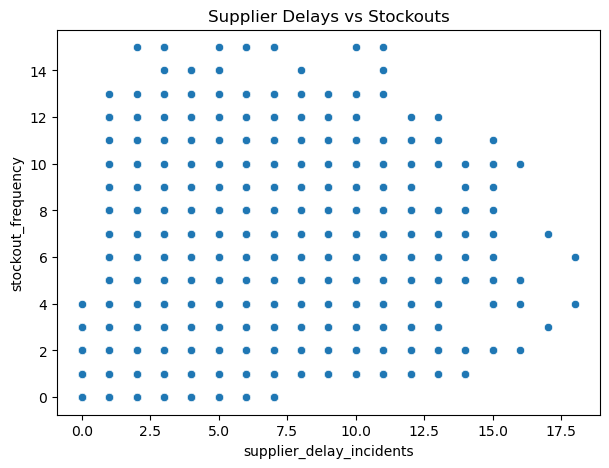

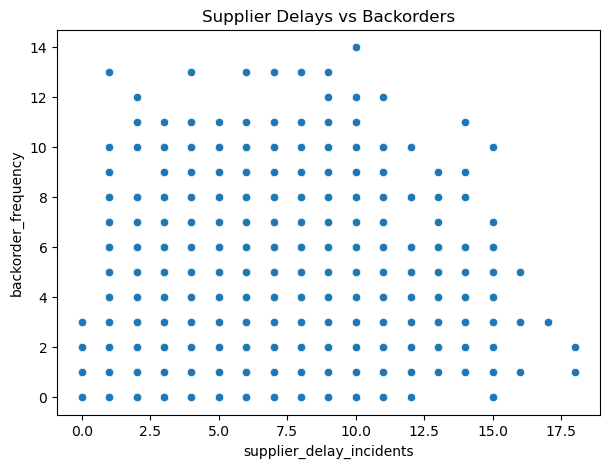

In [44]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='supplier_delay_incidents',
    y='stockout_frequency',
    data=df
)
plt.title("Supplier Delays vs Stockouts")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    x='supplier_delay_incidents',
    y='backorder_frequency',
    data=df
)
plt.title("Supplier Delays vs Backorders")
plt.show()

### Observation
Supplier delay incidents have a correlation of approximately 0.61 with stockout frequency and 0.57 with backorder frequency. This indicates that higher supplier delays are associated with more stockouts and backorders.

In [45]:
# Q17: Which products maintain significantly higher safety stock relative to their current stock?

df['safety_stock_ratio'] = df['safety_stock'] / df['current_stock']
df[['item_id', 'safety_stock_ratio']].sort_values( 'safety_stock_ratio', ascending=False).head(10)

,item_id,safety_stock_ratio
1475,ITM01476,inf
2472,ITM02473,inf
1625,ITM01626,inf
1176,ITM01177,inf
3981,ITM03982,inf
3007,ITM03008,18.000000
493,ITM00494,9.666667
2617,ITM02618,7.050000
1539,ITM01540,3.750000
1986,ITM01987,2.815789


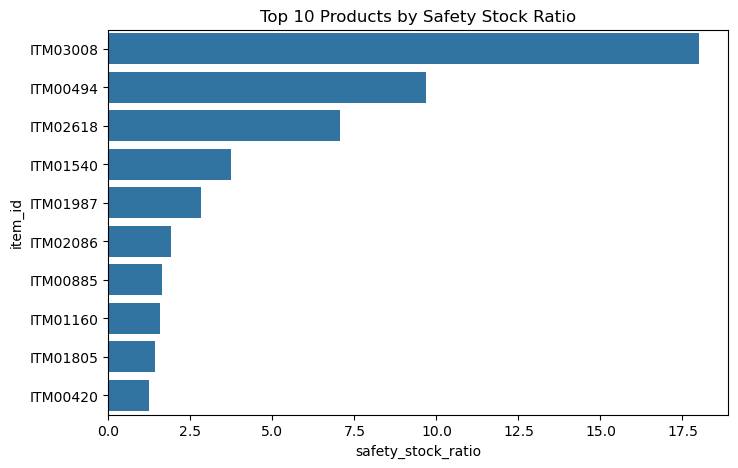

In [46]:
df['safety_stock_ratio'] = df['safety_stock'] / df['current_stock']

top10 = df.replace([np.inf, -np.inf], np.nan).nlargest(
    10, 'safety_stock_ratio'
)

plt.figure(figsize=(8,5))
sns.barplot(x='safety_stock_ratio', y='item_id', data=top10)
plt.title("Top 10 Products by Safety Stock Ratio")
plt.show()

### Observation
Some products have extremely high safety-stock ratios because their current stock is very low or zero. Products such as ITM03008 and ITM00494 have particularly high ratios among the finite values. This indicates that safety stock is large compared with the available current stock.

In [47]:
# Q18: Which products have high excess-stock levels?

df[['item_id', 'excess_stock_level']].sort_values('excess_stock_level', ascending=False).head(10)

,item_id,excess_stock_level
1018,ITM01019,622
2017,ITM02018,591
1375,ITM01376,568
2014,ITM02015,542
2509,ITM02510,539
3529,ITM03530,536
2314,ITM02315,503
3405,ITM03406,495
1171,ITM01172,487
3061,ITM03062,484


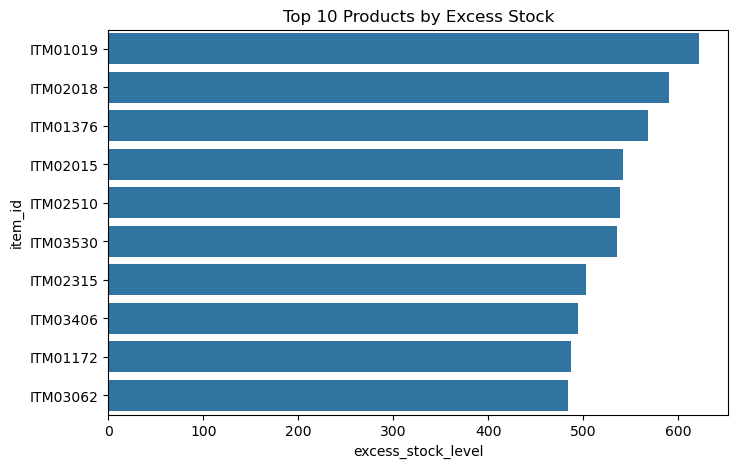

In [48]:
top10 = df.nlargest(10, 'excess_stock_level')

plt.figure(figsize=(8,5))
sns.barplot(x='excess_stock_level', y='item_id', data=top10)
plt.title("Top 10 Products by Excess Stock")
plt.show()

### Observation
ITM01019 has the highest excess stock level at 622 units, followed by ITM02018 at 591 units and ITM01376 at 568 units. These products have relatively large amounts of excess inventory.

In [49]:
# Q19: Is excess stock associated with high days in inventory?

print("Correlation:", round(df['excess_stock_level'].corr(df['days_in_inventory']), 2))

Correlation: 0.73


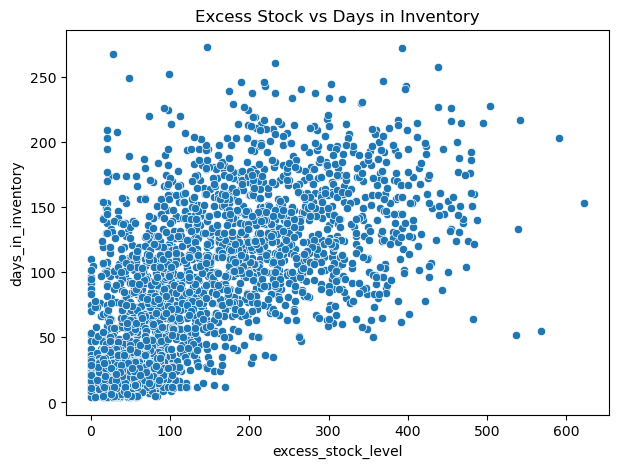

In [50]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='excess_stock_level',
    y='days_in_inventory',
    data=df
)
plt.title("Excess Stock vs Days in Inventory")
plt.show()

### Observation
The correlation is approximately 0.73, indicating a strong positive relationship. Products with higher excess stock tend to remain in inventory for more days. This suggests that excess inventory is an important factor associated with longer inventory holding periods.

In [51]:
# Q20: Which products have the highest inventory value?

df[['item_id', 'inventory_value']].sort_values('inventory_value', ascending=False).head(10)

,item_id,inventory_value
1253,ITM01254,2093353.52
155,ITM00156,1993974.96
706,ITM00707,1905333.80
3469,ITM03470,1902986.23
3718,ITM03719,1775518.85
1077,ITM01078,1699984.38
3085,ITM03086,1687486.24
1182,ITM01183,1632093.78
1598,ITM01599,1590946.24
3735,ITM03736,1563724.36


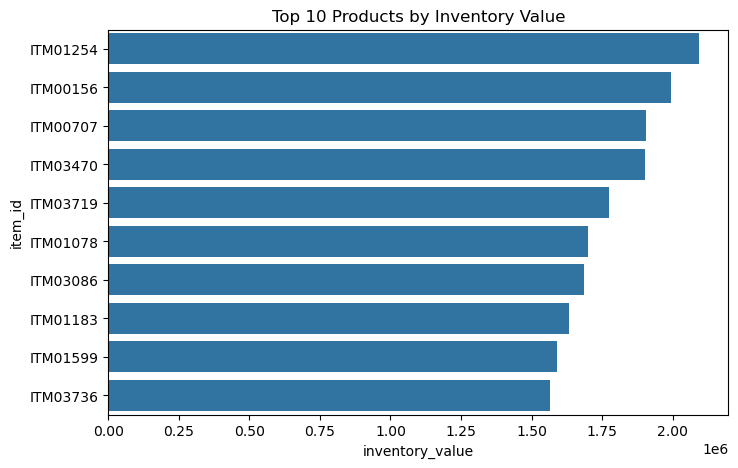

In [52]:
top10 = df.nlargest(10, 'inventory_value')

plt.figure(figsize=(8,5))
sns.barplot(x='inventory_value', y='item_id', data=top10)
plt.title("Top 10 Products by Inventory Value")
plt.show()

### Observation
ITM01254 has the highest inventory value at approximately 2.09 million, followed by ITM00156 and ITM00707. These products represent a significant amount of capital tied up in inventory.

In [53]:
# Q21: Which products have the highest holding cost per unit?

df[['item_id', 'holding_cost_per_unit']].sort_values('holding_cost_per_unit', ascending=False).head(10)

,item_id,holding_cost_per_unit
1253,ITM01254,502.57
2257,ITM02258,477.00
3547,ITM03548,470.56
3735,ITM03736,468.89
1977,ITM01978,427.05
706,ITM00707,391.89
3590,ITM03591,390.88
2765,ITM02766,380.79
2709,ITM02710,377.69
3663,ITM03664,353.22


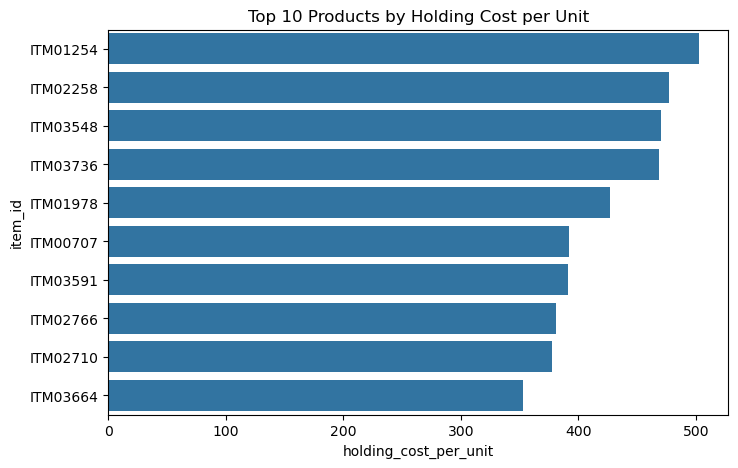

In [54]:
top10 = df.nlargest(10, 'holding_cost_per_unit')

plt.figure(figsize=(8,5))
sns.barplot(x='holding_cost_per_unit', y='item_id', data=top10)
plt.title("Top 10 Products by Holding Cost per Unit")
plt.show()

### Observation
ITM01254 has the highest holding cost per unit at approximately 502.57, followed by ITM02258 and ITM03548. These products are relatively expensive to keep in inventory.

In [55]:
# Q22: Do expensive products tend to have lower or higher stock turnover?

print("Correlation:", round(df['unit_cost'].corr(df['stock_turnover_ratio']), 2))

Correlation: -0.15


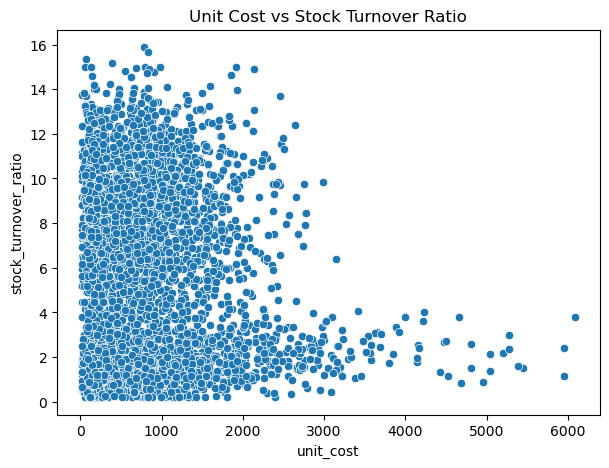

In [56]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='unit_cost',
    y='stock_turnover_ratio',
    data=df
)
plt.title("Unit Cost vs Stock Turnover Ratio")
plt.show()

### Observation
The correlation is approximately -0.15, indicating a weak negative relationship. Therefore, expensive products tend to have slightly lower stock turnover, but the relationship is weak.

In [57]:
# Q23: Which products have the highest return rates?

df[['item_id', 'return_rate']].sort_values('return_rate', ascending=False).head(10)

,item_id,return_rate
2359,ITM02360,0.080
2961,ITM02962,0.080
2623,ITM02624,0.080
2584,ITM02585,0.080
3520,ITM03521,0.079
823,ITM00824,0.079
2123,ITM02124,0.079
371,ITM00372,0.079
889,ITM00890,0.079
462,ITM00463,0.079


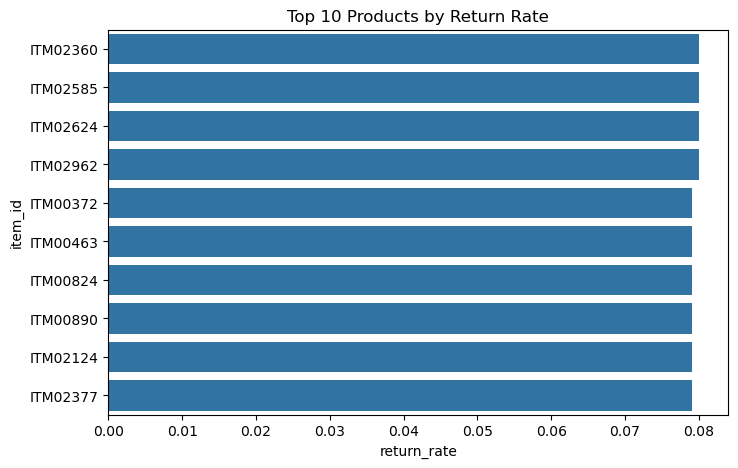

In [58]:
top10 = df.nlargest(10, 'return_rate')

plt.figure(figsize=(8,5))
sns.barplot(x='return_rate', y='item_id', data=top10)
plt.title("Top 10 Products by Return Rate")
plt.show()

### Observation
Several products have the highest return rate of approximately 0.08, including ITM02585, ITM02624 and ITM02360. These products have comparatively higher return rates and may require further investigation.

In [59]:
# Q24: Which products have the highest damage rates?

df[['item_id', 'damage_rate']].sort_values('damage_rate', ascending=False).head(10)

,item_id,damage_rate
1405,ITM01406,0.04
702,ITM00703,0.04
2627,ITM02628,0.04
1589,ITM01590,0.04
1160,ITM01161,0.04
2277,ITM02278,0.04
2813,ITM02814,0.04
1471,ITM01472,0.04
2055,ITM02056,0.04
3288,ITM03289,0.04


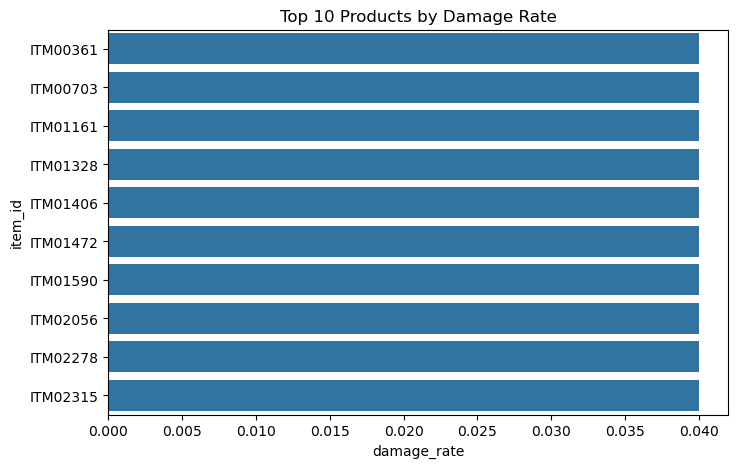

In [60]:
top10 = df.nlargest(10, 'damage_rate')

plt.figure(figsize=(8,5))
sns.barplot(x='damage_rate', y='item_id', data=top10)
plt.title("Top 10 Products by Damage Rate")
plt.show()

### Observation
Several products have the highest damage rate of 0.04, including ITM01328, ITM01472 and ITM01161. These products may require additional attention to handling, storage, or packaging.

In [61]:
# Q25: Are high return and damage rates concentrated in particular categories or warehouse zones?

print("Return and damage rates by category:")
print(df.groupby('category')[['return_rate', 'damage_rate']].mean())

print("\nReturn and damage rates by warehouse zone:")
print(df.groupby('warehouse_zone')[['return_rate', 'damage_rate']].mean())

Return and damage rates by category:
                return_rate  damage_rate
category                                
Apparel            0.027494     0.015663
Automotive         0.028767     0.015972
Electronics        0.029620     0.015857
Grocery            0.028346     0.015689
Home & Kitchen     0.029095     0.015636
Industrial         0.028432     0.015564
Pharmaceutical     0.028216     0.014996
Stationery         0.027907     0.016324

Return and damage rates by warehouse zone:
                return_rate  damage_rate
warehouse_zone                          
A1                 0.028317     0.016032
A2                 0.028528     0.016478
B1                 0.029092     0.015939
B2                 0.028460     0.015769
C1                 0.027777     0.014905
C2                 0.028894     0.015542
D1                 0.027563     0.015376
D2                 0.029318     0.015727


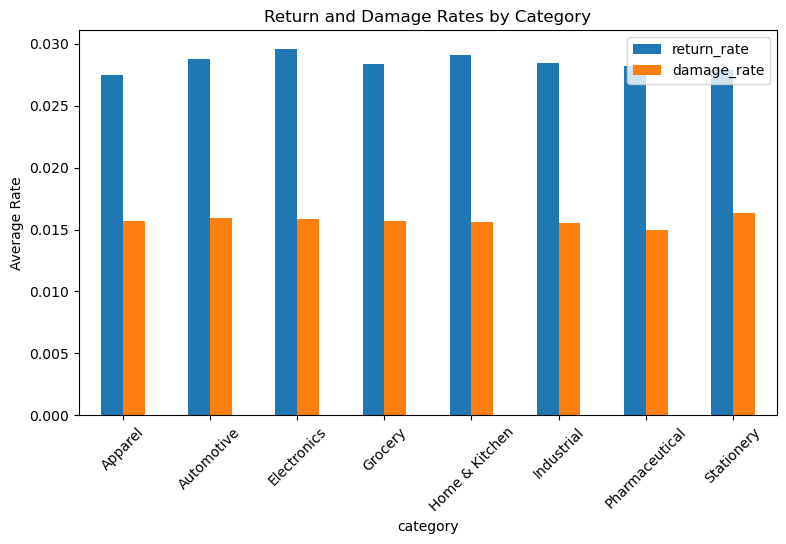

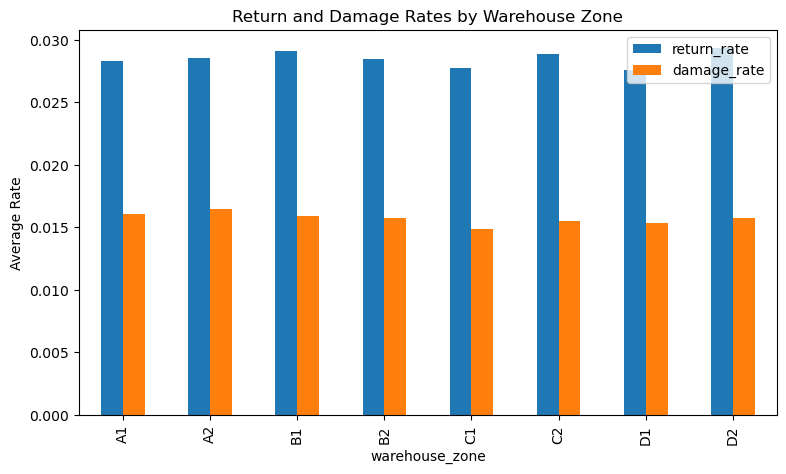

In [62]:
category_rates = df.groupby('category')[['return_rate', 'damage_rate']].mean()

category_rates.plot(kind='bar', figsize=(9,5))
plt.title("Return and Damage Rates by Category")
plt.ylabel("Average Rate")
plt.xticks(rotation=45)
plt.show()

zone_rates = df.groupby('warehouse_zone')[['return_rate', 'damage_rate']].mean()

zone_rates.plot(kind='bar', figsize=(9,5))
plt.title("Return and Damage Rates by Warehouse Zone")
plt.ylabel("Average Rate")
plt.show()

### Observation
Return rates are relatively similar across categories, with Electronics having the highest average return rate. Damage rates are also fairly similar, with Stationery having the highest average damage rate.

Across warehouse zones, D2 has the highest average return rate, while A2 has the highest average damage rate. Overall, the differences between categories and zones are relatively small.

In [63]:
# Q26: Which products have the highest warehouse demand pressure index?

df[['item_id', 'warehouse_demand_pressure_index']].sort_values('warehouse_demand_pressure_index', ascending=False).head(10)

,item_id,warehouse_demand_pressure_index
2152,ITM02153,300.0
3377,ITM03378,300.0
3317,ITM03318,300.0
3313,ITM03314,300.0
3306,ITM03307,300.0
3304,ITM03305,300.0
3298,ITM03299,300.0
3294,ITM03295,300.0
824,ITM00825,300.0
2002,ITM02003,300.0


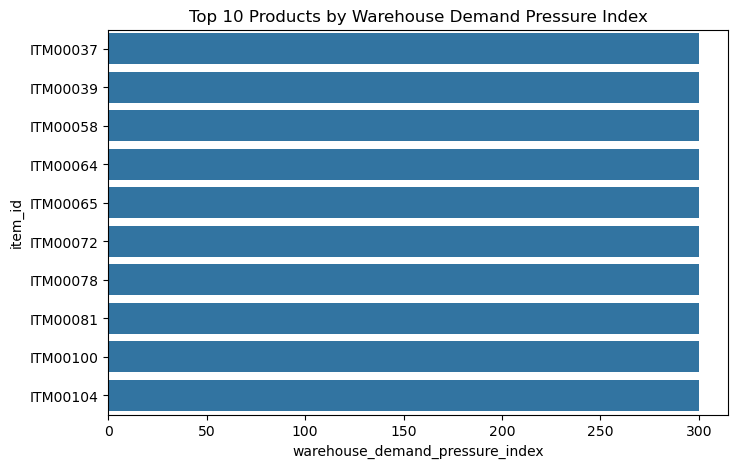

In [64]:
top10 = df.nlargest(10, 'warehouse_demand_pressure_index')

plt.figure(figsize=(8,5))
sns.barplot(
    x='warehouse_demand_pressure_index',
    y='item_id',
    data=top10
)
plt.title("Top 10 Products by Warehouse Demand Pressure Index")
plt.show()

### Observation
The highest warehouse demand pressure index is 300, and multiple products share this value. These products experience the highest level of warehouse demand pressure in the dataset and may require closer inventory monitoring.

# Final Business Insights

- Average demand varies between product categories, with **Pharmaceutical** products having the highest demand.
- **Electronics** shows the greatest demand variability, making demand prediction more challenging.
- **Warehouse Zone D1** records the highest average demand.
- Higher lead-time variability is associated with more supplier delay incidents.
- Products with higher stock turnover generally have fewer days in inventory.
- Greater demand variability is associated with an increase in stockout frequency.
- Products experiencing more stockouts also tend to have more backorders.
- Supplier delays are linked with higher levels of stockouts and backorders.
- Higher excess stock is associated with products remaining in inventory for longer periods.
- Products with high inventory values and holding costs require closer monitoring.
- Return and damage rates vary to some extent across categories and warehouse zones.
- Products with very high warehouse demand pressure should receive additional attention for inventory planning.

# Conclusion

The warehouse dataset is clean, with **4,000 records, 25 columns, no missing values, and no duplicate records**. The analysis highlights several important factors affecting warehouse performance, including demand patterns, supplier reliability, replenishment, inventory turnover, excess stock, and product quality.

These insights can help in **improving demand planning, optimizing safety stock, monitoring suppliers, reducing stockouts and excess inventory, planning warehouse capacity, and controlling inventory-related costs**.

> **Note:** Correlation indicates a relationship between variables, but it does not establish a direct cause-and-effect relationship.

# SCALING AND ENCODING

In [103]:
df1 = df.copy()

In [104]:
df_dropped = df1.drop(columns=['item_id', 'supplier_id'])

In [105]:
cat_cols = ['category', 'subcategory', 'warehouse_zone',
            'warehouse_demand_pressure_index']

num_cols = [
    'avg_monthly_demand', 'demand_variability',
    'avg_lead_time_days', 'lead_time_variability',
    'monthly_reorder_count', 'stock_turnover_ratio',
    'days_in_inventory', 'stockout_frequency',
    'backorder_frequency', 'return_rate', 'damage_rate',
    'holding_cost_per_unit', 'unit_cost',
    'reorder_point_breaches', 'supplier_delay_incidents',
    'current_stock', 'safety_stock', 'excess_stock_level',
    'inventory_value'
]

In [106]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df_dropped[col] = le.fit_transform(df_dropped[col])

In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_dropped[num_cols] = scaler.fit_transform(df_dropped[num_cols])

In [108]:
df_encoded = df_dropped

In [109]:
X = df_encoded

In [110]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   category                         4000 non-null   int64  
 1   subcategory                      4000 non-null   int64  
 2   warehouse_zone                   4000 non-null   int64  
 3   avg_monthly_demand               4000 non-null   float64
 4   demand_variability               4000 non-null   float64
 5   avg_lead_time_days               4000 non-null   float64
 6   lead_time_variability            4000 non-null   float64
 7   monthly_reorder_count            4000 non-null   float64
 8   stock_turnover_ratio             4000 non-null   float64
 9   days_in_inventory                4000 non-null   float64
 10  stockout_frequency               4000 non-null   float64
 11  backorder_frequency              4000 non-null   float64
 12  return_rate         

# KMEANS 

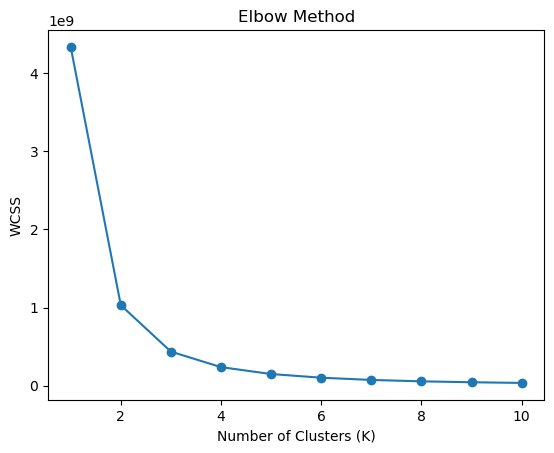

In [111]:
from sklearn.cluster import KMeans

wcss = []  # List to store WCSS(error) for different values of K

# Loop through different values of K (number of clusters)
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)  # Create K-Means model
    kmeans.fit(X)  # Train model on scaled data
    wcss.append(kmeans.inertia_)  # Stores WCSS (within-cluster error)

plt.figure()
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [112]:
kmeans_3 = KMeans(n_clusters=3, random_state=42)  # Create K-Means model with 3 clusters
df_encoded["Cluster_3"] = kmeans_3.fit_predict(X)  # Train model and assign cluster labels

In [115]:
kmeans_4 = KMeans(n_clusters=4, random_state=42)  # Create K-Means model with 4 clusters
df_encoded["Cluster_4"] = kmeans_4.fit_predict(X)  # Train model and assign cluster labels

In [113]:
df_encoded.groupby("Cluster_3").mean()
# Group the data by Cluster_3 and calculate the average of each column
# This helps us understand the characteristics of each cluster

,category,subcategory,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,...,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
Cluster_3,,,,,,,,,,,,,,,,,,,,,
0,3.443580,19.442023,3.438911,-0.947917,0.189108,-0.169237,-0.313961,-0.909113,-0.946761,1.054215,...,0.378037,0.256721,0.276468,-0.579579,-0.454620,-0.020561,-0.953119,1.118911,0.212498,596.350973
1,3.546224,19.321807,3.501764,0.282674,0.378297,0.556417,0.777192,0.465286,0.332211,-0.474599,...,0.038066,-0.159293,-0.164961,0.898586,0.824757,-0.406185,0.461736,-0.578055,-0.274975,3000.589273
2,3.444530,19.259630,3.535439,0.629834,-0.600192,-0.439887,-0.537628,0.392065,0.574611,-0.525547,...,-0.415807,-0.080254,-0.093615,-0.407194,-0.450304,0.463778,0.439506,-0.476654,0.089815,1805.052388


In [116]:
df_encoded.groupby("Cluster_4").mean()
# Group the data by Cluster_4 and calculate the average of each column
# This helps us understand the characteristics of each cluster

,category,subcategory,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,...,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index,Cluster_3
Cluster_4,,,,,,,,,,,,,,,,,,,,,
0,3.490625,19.300000,3.440625,-1.157226,0.387103,-0.101456,-0.233000,-1.082493,-1.139215,1.266193,...,0.211047,0.229668,-0.580885,-0.448357,-0.071951,-1.127430,1.470793,0.173237,444.463542,0.000000
1,3.549259,19.360070,3.437663,0.194326,0.458590,0.651012,0.902080,0.465774,0.300206,-0.458073,...,-0.165843,-0.170030,1.036212,0.970368,-0.557267,0.394336,-0.589430,-0.341305,3110.758500,1.000000
2,3.468553,19.077568,3.628931,0.665448,-0.335350,-0.165828,-0.173746,0.423488,0.520439,-0.539635,...,-0.135982,-0.145749,-0.117155,-0.150973,0.270913,0.588354,-0.504002,-0.013598,2215.117400,1.716981
3,3.397231,19.624068,3.473908,0.269657,-0.615226,-0.523018,-0.687169,0.107500,0.269236,-0.186713,...,0.124966,0.120966,-0.552842,-0.573548,0.479027,0.073204,-0.271638,0.253612,1334.565495,1.307774


## Observation

The cluster profile compares the average business characteristics of the four warehouse segments (Cluster 0, Cluster 1, Cluster 2, and Cluster 3) based on the standardized feature values.

* Cluster 0: Shows relatively low average monthly demand and low reorder activity, along with lower stock turnover. This cluster represents warehouses with comparatively lower-demand and lower-activity inventory operations.
* Cluster 1: Shows high average monthly demand with relatively low demand variability and shorter lead times. The reorder activity is also relatively high, indicating warehouses with consistent demand and more predictable inventory requirements.
* Cluster 2: Has relatively lower demand but high average lead time and high lead-time variability. This suggests warehouses that may face longer and less predictable replenishment times, requiring careful inventory planning.
* Cluster 3: Shows high demand and high demand variability, along with higher lead-time variability and reorder activity. This represents warehouses with more dynamic and demanding inventory requirements, where effective forecasting and safety-stock management are important.

Overall, the four clusters represent distinct warehouse operating patterns. Cluster 0 is characterized by lower activity, Cluster 1 by stable high demand, Cluster 2 by longer and variable lead times, and Cluster 3 by high and more variable demand. These segments can help management develop different inventory and replenishment strategies for each warehouse group.

### Cluster Insights

The K-Means model has divided the warehouses into four distinct clusters: Cluster 0, Cluster 1, Cluster 2, and Cluster 3. The cluster averages show clear differences in demand, lead time, reorder activity, and inventory-related characteristics.

* Cluster 0 — Low-Demand / Low-Reorder Warehouses

Interpretation: Cluster 0 represents warehouses with relatively low average monthly demand and the lowest reorder activity among the four clusters. Demand variability is moderate, while lead-time-related measures are comparatively low. This indicates a segment with lower inventory movement and lower replenishment requirements.

* Cluster 1 — Stable High-Demand Warehouses

Interpretation: Cluster 1 represents warehouses with high average monthly demand but relatively low demand variability. They also have comparatively lower lead times and lower lead-time variability, while reorder activity is relatively high. This suggests a segment with consistent demand and predictable replenishment requirements, making it suitable for efficient and regular inventory planning.

* Cluster 2 — Long and Variable Lead-Time Warehouses

Interpretation: Cluster 2 is characterized by low average monthly demand but the highest average lead time and high lead-time variability. Reorder activity is relatively low compared with the more active segments. This indicates warehouses where replenishment takes longer and is less predictable, requiring careful planning to avoid inventory shortages.

* Cluster 3 — High-Demand / High-Variability Warehouses

Interpretation: Cluster 3 represents warehouses with high average monthly demand and the highest demand variability. Lead time and lead-time variability are also relatively high, while reorder activity remains comparatively higher than the low-demand segments. This indicates a more dynamic warehouse segment with greater inventory-management requirements.

## Visuale the cluster using the PCA

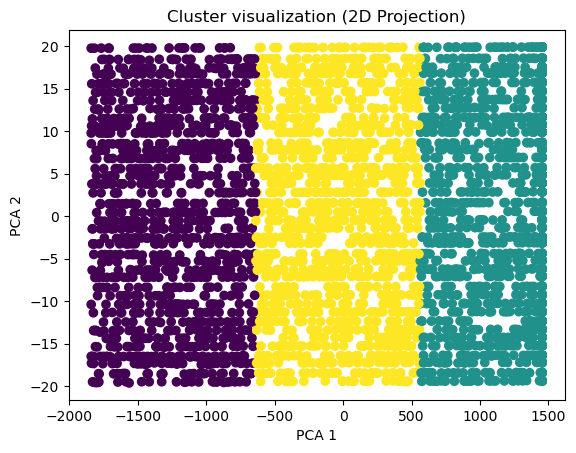

In [118]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_encoded["Cluster_3"])

plt.title("Cluster visualization (2D Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

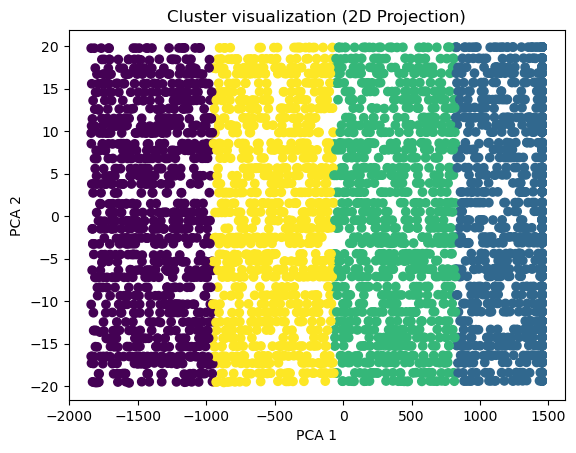

In [117]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_encoded["Cluster_4"])

plt.title("Cluster visualization (2D Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## Overall Insight

The clustering analysis identifies four distinct warehouse segments based on their operational and inventory characteristics. Cluster 0 represents lower-demand and lower-reorder warehouses, Cluster 1 represents stable high-demand warehouses, Cluster 2 is mainly characterized by longer and more variable replenishment times, and Cluster 3 represents high-demand warehouses with greater demand variability.

## Final Project Insight

The analysis shows that warehouses do not have the same demand and replenishment behavior, so a single inventory strategy may not be suitable for all warehouses. Different strategies can be applied to each cluster: Cluster 0 can focus on controlling excess inventory, Cluster 1 can focus on maintaining efficient replenishment, Cluster 2 can focus on managing lead-time uncertainty and safety stock, and Cluster 3 can focus on accurate demand forecasting and stronger inventory planning.

Therefore, the K-Means clustering provides meaningful warehouse segmentation that can support data-driven inventory management, replenishment planning, and operational decision-making.

